In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split

from quotaclimat.data_processing.factiva.explo_optimal_thresholds.utils_explo.utils_explo import (
    create_llm_columns_from_secteurs,
    create_keyword_sector_columns,
    test_thresholds_all_sectors,
    plot_threshold_metrics_by_sector,
    plot_nb_predicted_articles_by_sector
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

DATA_PATH = 'quotaclimat/data_processing/factiva/explo_optimal_thresholds/data_explo/factiva_sectors.xlsx'

In [35]:
df = pd.read_excel(DATA_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

# Create LLM columns

In [36]:
df = create_llm_columns_from_secteurs(df)

✓ LLM sector columns created from 'llm_secteurs'
  Total articles: 2182
  Sector distribution (count, % of total):
    - llm_agri_alim: 634 articles (29.1%)
    - llm_batiment: 760 articles (34.8%)
    - llm_eau: 403 articles (18.5%)
    - llm_economie_circulaire: 480 articles (22.0%)
    - llm_ecosysteme: 852 articles (39.0%)
    - llm_energie: 778 articles (35.7%)
    - llm_industrie: 475 articles (21.8%)
    - llm_mobilite: 444 articles (20.3%)


# Count number of keywords for each sector

In [26]:
df['all_keywords'] = df['all_keywords'].astype(str)

In [37]:
df = create_keyword_sector_columns(df, keywords_col="all_keywords")

✓ Keyword sector count columns created from 'all_keywords'
  Total articles: 2182
  Keyword sector distribution (total keywords per sector):
    - nb_agri_alim: 3133 keywords
    - nb_mobilite: 1710 keywords
    - nb_batiment: 2251 keywords
    - nb_energie: 2613 keywords
    - nb_industrie: 2336 keywords
    - nb_eau: 1239 keywords
    - nb_ecosysteme: 6973 keywords
    - nb_economie_circulaire: 1232 keywords


c:\Documents\Ome\Audiovisuel\quotaclimat\quotaclimat\data_processing\factiva\explo_optimal_thresholds\utils_explo\utils_explo.py:75: UserWarning: Found 13 keywords not in MACRO_CATEGORIES. First 10: ['énergie fossile', 'éleveurs', 'pollution de l’eau', 'invendu', 'agropastoralisme', "préservation de l'environnement", "réserve d'eau", 'ralentir', 'rénovation des bâtiments', "pollution de l'air"]
  def _build_sector_flags(value) -> Dict[str, int]:


# Determine optimal thresholds

In [39]:
results_secteurs = test_thresholds_all_sectors(
    df,
    thresholds=list(range(1, 11)),
)

In [43]:
results_secteurs[results_secteurs.sector == 'eau']

,precision,recall,f1_score,precision_recall_ratio,true_positives,false_positives,true_negatives,false_negatives,total_predicted_positive,total_true_positive,threshold,sector
40,0.502786,0.895782,0.644068,0.561281,361,357,1422,42,718,403,1,eau
41,0.762774,0.518610,0.617430,1.470803,209,65,1714,194,274,403,2,eau
42,0.914729,0.292804,0.443609,3.124031,118,11,1768,285,129,403,3,eau
43,0.966102,0.141439,0.246753,6.830508,57,2,1777,346,59,403,4,eau
44,1.000000,0.076923,0.142857,13.000000,31,0,1779,372,31,403,5,eau
45,1.000000,0.039702,0.076372,25.187500,16,0,1779,387,16,403,6,eau
46,1.000000,0.017370,0.034146,57.571429,7,0,1779,396,7,403,7,eau
47,1.000000,0.007444,0.014778,134.333333,3,0,1779,400,3,403,8,eau
48,1.000000,0.004963,0.009877,201.500000,2,0,1779,401,2,403,9,eau
49,0.000000,0.000000,0.000000,inf,0,0,1779,403,0,403,10,eau


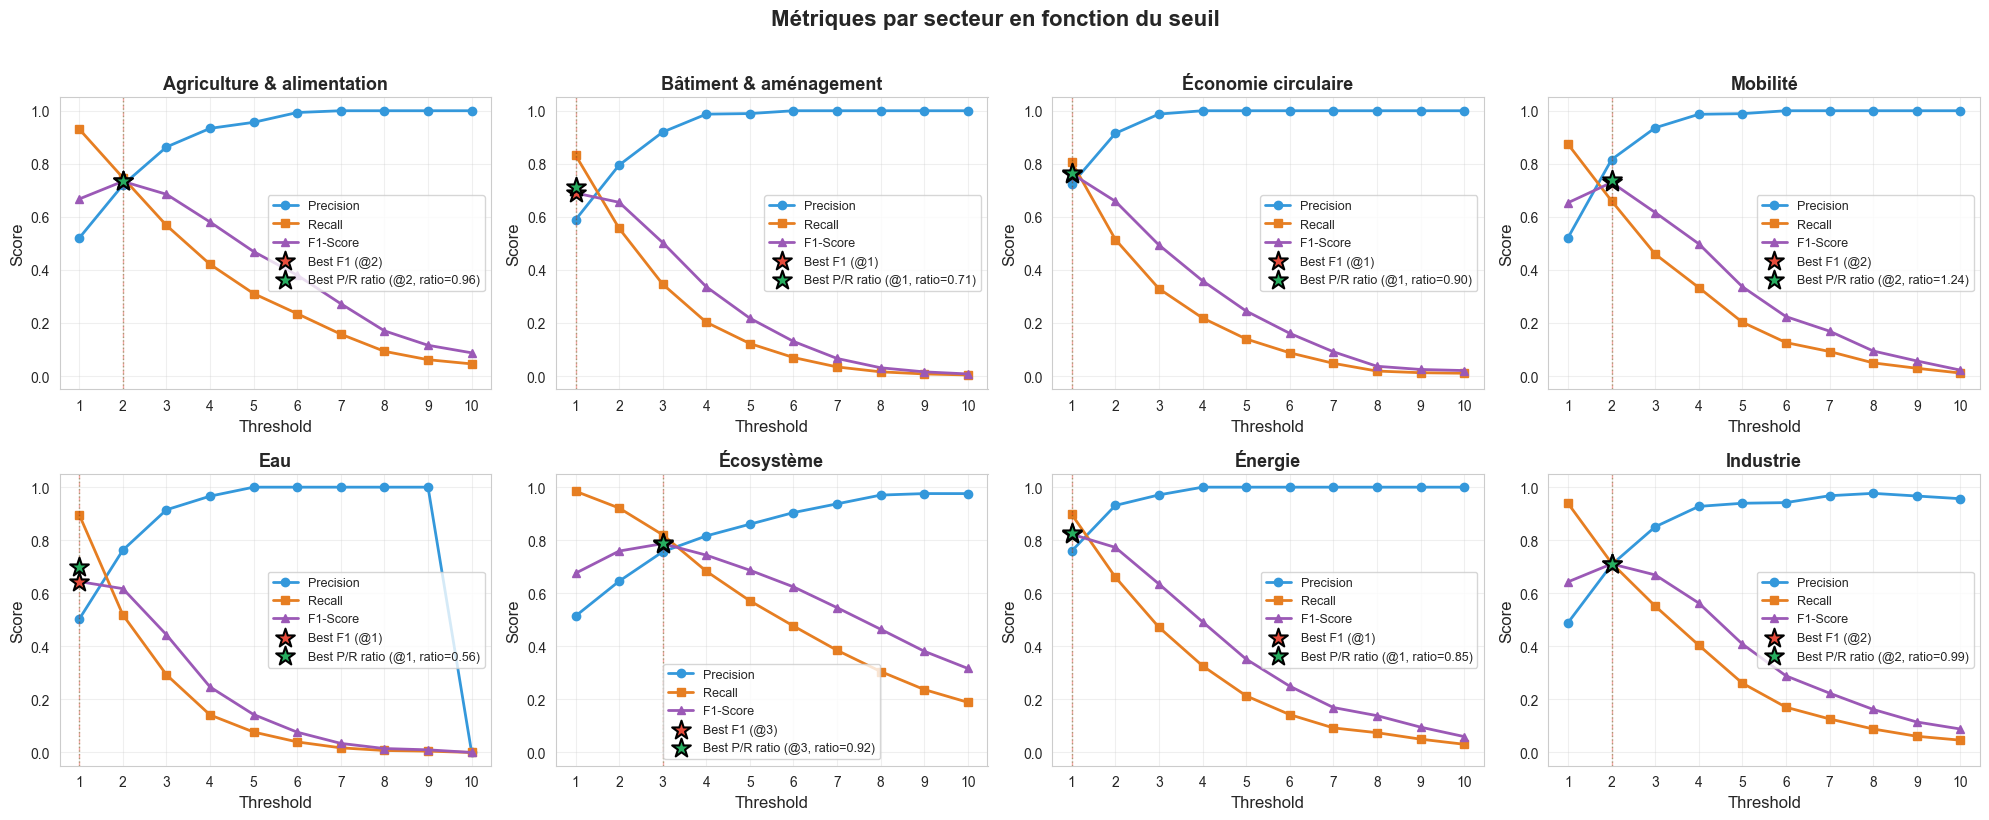

In [40]:
plot_threshold_metrics_by_sector(results_secteurs)

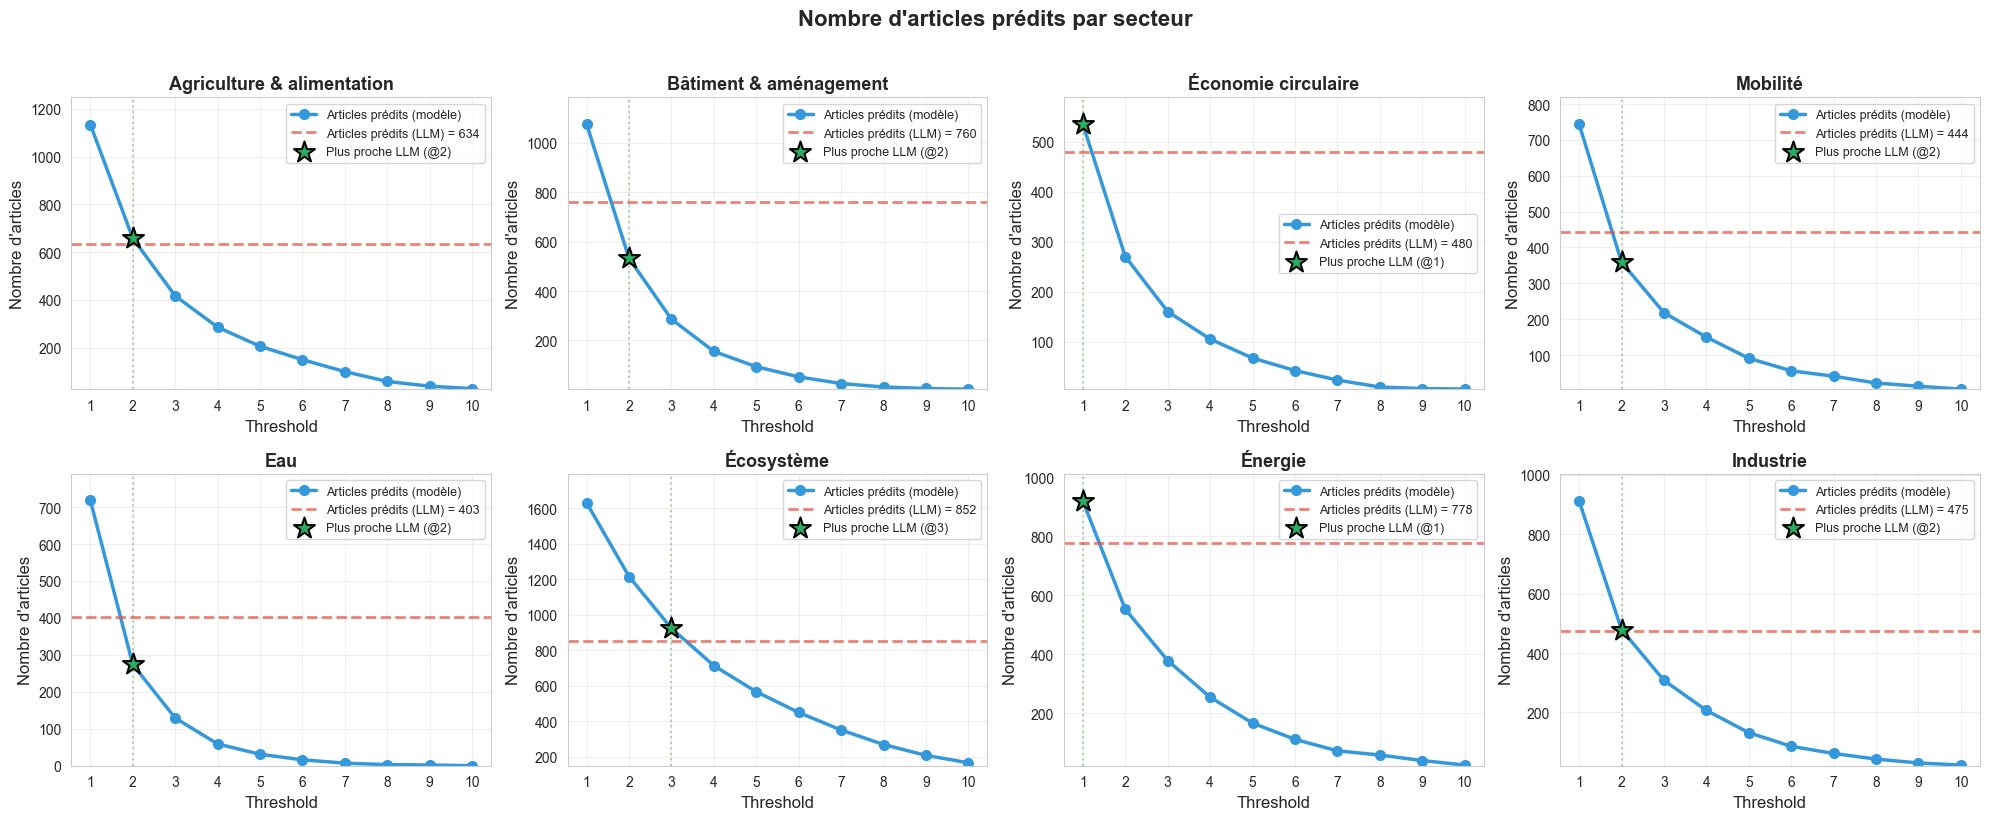

In [41]:
plot_nb_predicted_articles_by_sector(results_secteurs)